C:\Users\Nilavra Ghosh\AppData\Local\Temp\ipykernel_24364\4042505402.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, skiprows=header_idx, delim_whitespace=True)



--- Performance Parameters for NACA4415 ---
 alpha       CL     CL/CD  CL^1.5/CD        CM
   0.0 0.283105 18.973594  10.095396 -0.170901
   0.5 0.315374 19.275961  10.825027 -0.178465
   1.0 0.347590 19.366503  11.417864 -0.186011
   1.5 0.379746 19.355046  11.927263 -0.193539
   2.0 0.411837 19.226751  12.338676 -0.201045
   2.5 0.443854 18.994094  12.654316 -0.208528
   3.0 0.475793 18.625680  12.847575 -0.215985
   3.5 0.507645 18.182128  12.954622 -0.223415
   4.0 0.539406 17.686602  12.989795 -0.230816
   4.5 0.571068 17.163105  12.969994 -0.238185
   5.0 0.602625 16.636529  12.914759 -0.245522
   5.5 0.634070 16.120970  12.836889 -0.252822
   6.0 0.665399 15.622629  12.743690 -0.260084
   6.5 0.696603 15.143214  12.638942 -0.267306
   7.0 0.727678 14.682768  12.524995 -0.274485
   7.5 0.758617 14.240980  12.403697 -0.281620
   8.0 0.789414 13.815194  12.274658 -0.288709
   8.5 0.820063 13.410679  12.144353 -0.295749
   9.0 0.850558 13.024393  12.011838 -0.302738
   9.5 0.880894

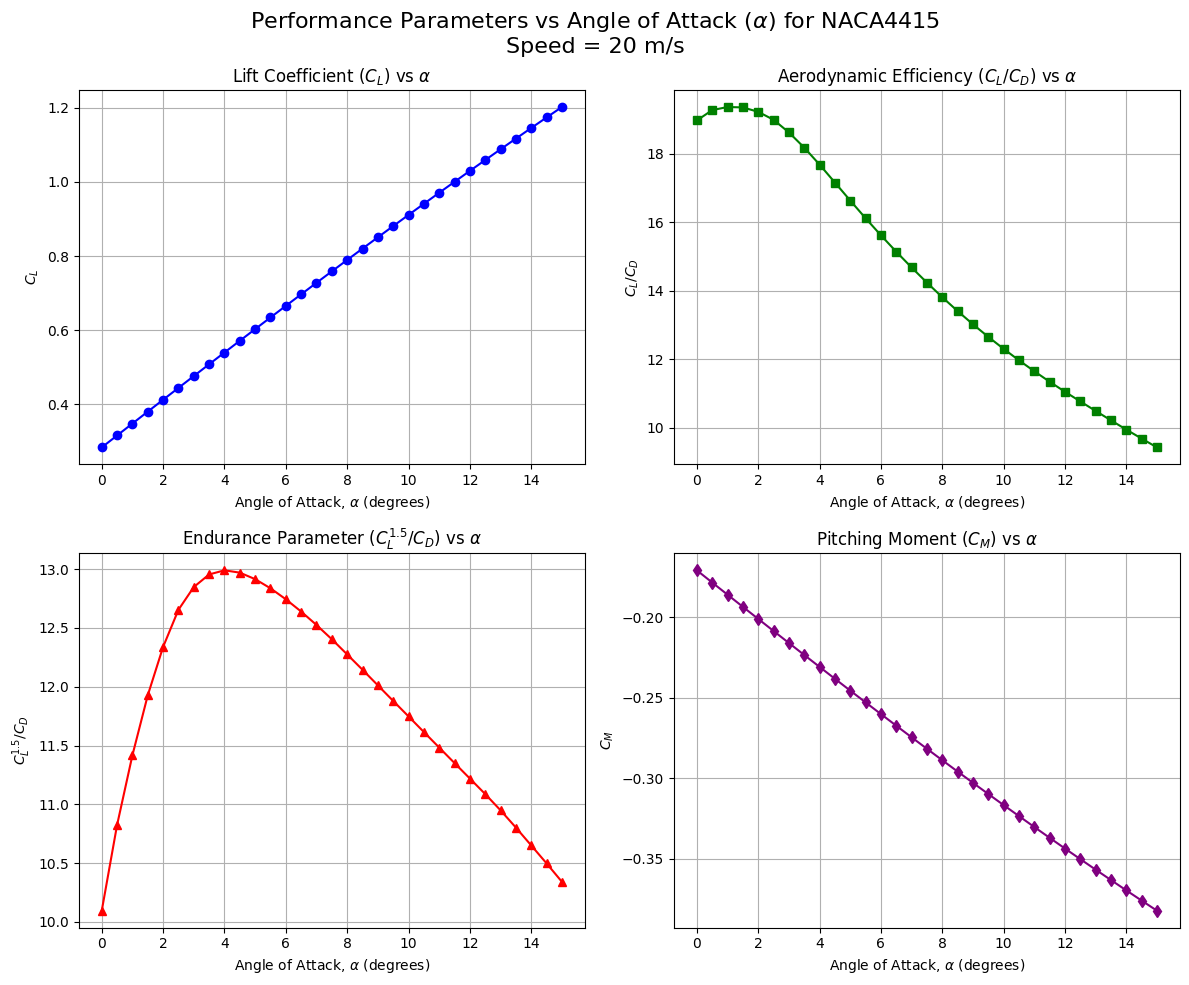

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(2023102006)

def analyze_airfoil_data(file_path, airfoil_name):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        
    header_idx = -1
    for i, line in enumerate(lines):
        if 'alpha' in line and 'CL' in line and 'CD' in line:
            header_idx = i
            break
            
    if header_idx == -1:
        raise ValueError(f"Could not find the data table in {file_path}. Check the file format.")

    df = pd.read_csv(file_path, skiprows=header_idx, delim_whitespace=True)

    df['CL/CD'] = df['CL'] / df['CD']
    df['CL^1.5/CD'] = (df['CL']**1.5) / df['CD']
    df.rename(columns={'Cm': 'CM'}, inplace=True)

    results_df = df[['alpha', 'CL', 'CL/CD', 'CL^1.5/CD', 'CM']].copy()

    print(f"\n--- Performance Parameters for {airfoil_name} ---")
    print(results_df.to_string(index=False))

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Performance Parameters vs Angle of Attack ($\\alpha$) for {airfoil_name}\nSpeed = 20 m/s', fontsize=16)

    axs[0, 0].plot(results_df['alpha'], results_df['CL'], marker='o', color='b', label='CL')
    axs[0, 0].set_title(r'Lift Coefficient ($C_L$) vs $\alpha$')
    axs[0, 0].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[0, 0].set_ylabel(r'$C_L$')
    axs[0, 0].grid(True)

    axs[0, 1].plot(results_df['alpha'], results_df['CL/CD'], marker='s', color='g', label='CL/CD')
    axs[0, 1].set_title(r'Aerodynamic Efficiency ($C_L/C_D$) vs $\alpha$')
    axs[0, 1].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[0, 1].set_ylabel(r'$C_L / C_D$')
    axs[0, 1].grid(True)

    axs[1, 0].plot(results_df['alpha'], results_df['CL^1.5/CD'], marker='^', color='r', label='CL^1.5/CD')
    axs[1, 0].set_title(r'Endurance Parameter ($C_L^{1.5}/C_D$) vs $\alpha$')
    axs[1, 0].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[1, 0].set_ylabel(r'$C_L^{1.5} / C_D$')
    axs[1, 0].grid(True)

    axs[1, 1].plot(results_df['alpha'], results_df['CM'], marker='d', color='purple', label='CM')
    axs[1, 1].set_title(r'Pitching Moment ($C_M$) vs $\alpha$')
    axs[1, 1].set_xlabel(r'Angle of Attack, $\alpha$ (degrees)')
    axs[1, 1].set_ylabel(r'$C_M$')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

FILE_PATH = 'NACA4415_T1-20_0 m_s-VLM1.txt'  
AIRFOIL_NAME = 'NACA4415'    

analyze_airfoil_data(FILE_PATH, AIRFOIL_NAME)